# 🌟 Week 2 — Day 5: EDA Part 2 — Correlation & Data Storytelling

**BinX Tech — AI & Machine Learning Internship Program**

![status](https://img.shields.io/badge/status-in--progress-yellow)
![python](https://img.shields.io/badge/python-3.10%2B-blue)
![libraries](https://img.shields.io/badge/libraries-Seaborn%20%7C%20Pandas%20%7C%20Matplotlib-orange)
![milestone](https://img.shields.io/badge/milestone-Week%202%20Centerpiece-9146FF)

---

| | |
|---|---|
| **Day** | Day 5 of 5 — Week 2 Centerpiece |
| **Duration** | 8 hours |
| **Tools** | Seaborn • Pandas • Matplotlib • Jupyter Notebook • Git & GitHub |
| **Dataset** | Titanic |

---

## 🎯 Learning Objectives

- Perform bivariate analysis with scatter plots and grouped box plots.
- Compute and interpret a correlation matrix and heatmap.
- Assemble a complete, narrated EDA notebook on a real dataset.

---

## 💡 Why This Day Matters Most

This notebook is the **template for the EDA stage of every project through the Phase 3 capstone**.
It combines everything from this week — descriptive statistics (Day 1), probability intuition
(Day 2), the math foundations (Day 3), and univariate distributions (Day 4) — into one complete,
narrated analysis. The deliverable isn't the charts; it's the **understanding communicated
clearly**.

---


## 🔧 Step 0 — Environment Setup

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.precision", 2)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 📂 Step 1 — Load the Dataset

In [2]:
df = sns.load_dataset("titanic")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


## 🔗 Step 2 — Bivariate Analysis

Bivariate analysis examines the relationship between two variables — the step where genuine
insight usually appears, since ML is fundamentally about relationships between features and a
target.

### Scatter Plot — Age vs. Fare


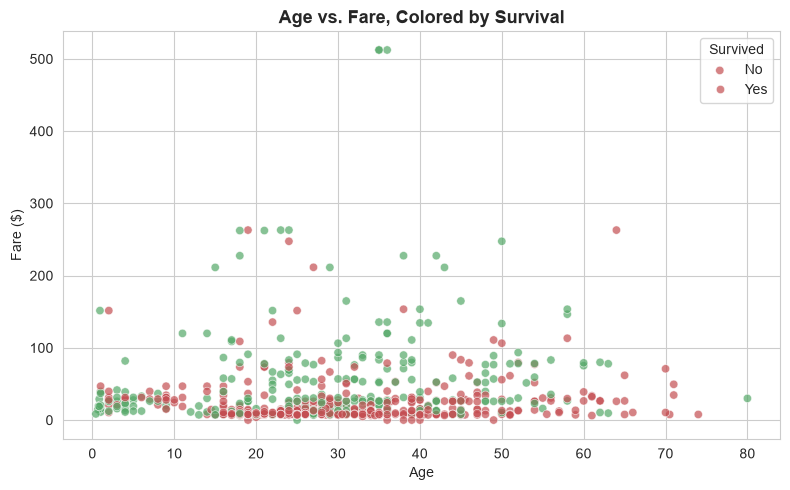

In [3]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="fare", hue="survived", palette={0: "#C44E52", 1: "#55A868"}, alpha=0.7)
plt.title("Age vs. Fare, Colored by Survival", fontsize=13, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Fare ($)")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


**What this shows:** *(fill in — is there any visible relationship between age and fare? Does
survival appear to cluster in any particular region of the plot?)*

### Grouped Box Plot — Fare by Class


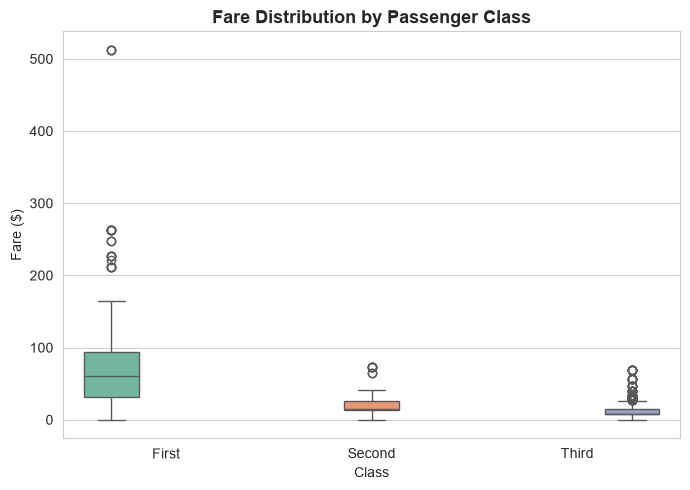

In [4]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="class", y="fare", hue="class", palette="Set2", legend=False)
plt.title("Fare Distribution by Passenger Class", fontsize=13, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Fare ($)")
plt.tight_layout()
plt.show()


**What this shows:** *(fill in — how does the median fare differ across classes? Which class
has the widest spread, and why might that be?)*

### Grouped Box Plot — Age by Survival


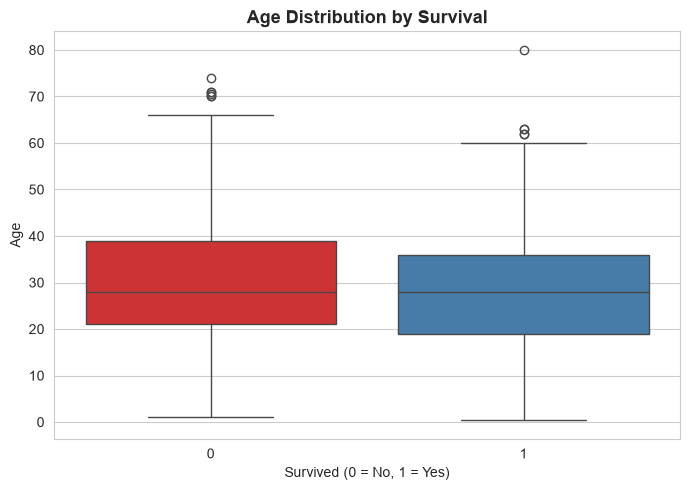

In [5]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="survived", y="age", hue="survived", palette="Set1", legend=False)
plt.title("Age Distribution by Survival", fontsize=13, fontweight="bold")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


**What this shows:** *(fill in — does age appear to have a meaningful relationship with
survival, or do the two groups look similar?)*

---

## 🌡️ Step 3 — Correlation Analysis

Correlation measures how strongly two numeric variables move together, on a scale from -1 to +1.
A correlation heatmap shows every pair of variables' correlations at once.

> ⚠️ **Correlation is not causation** — two variables moving together does not mean one causes the
> other. EDA identifies relationships; it never proves cause.


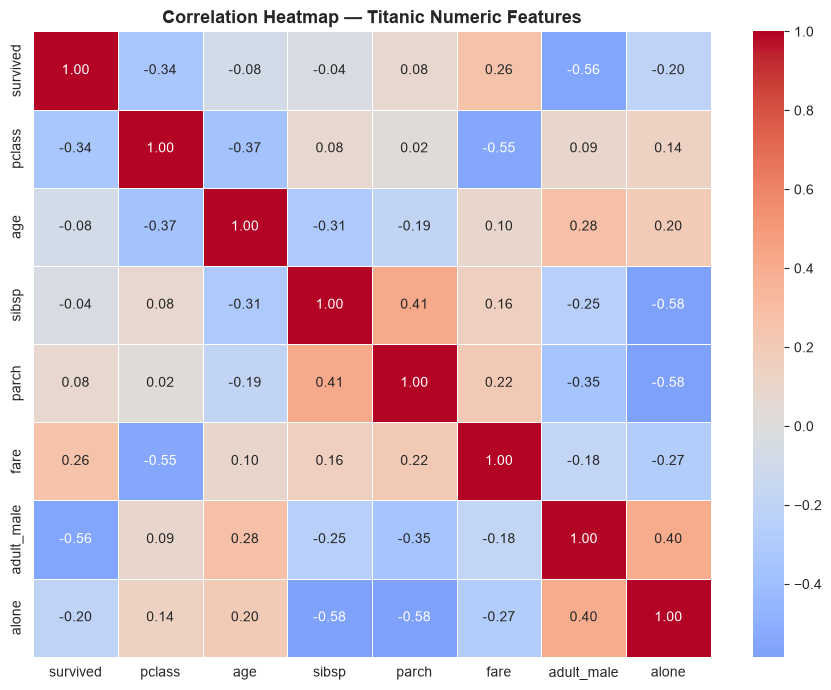

In [6]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, center=0)
plt.title("Correlation Heatmap — Titanic Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 📝 Interpretation

*(Fill this in — identify the two or three strongest correlations (positive or negative) and
explain what they might mean. Remember: describe the relationship, don't claim causation.)*

---

## 🕸️ Step 4 — The Pairplot: Scanning All Relationships at Once


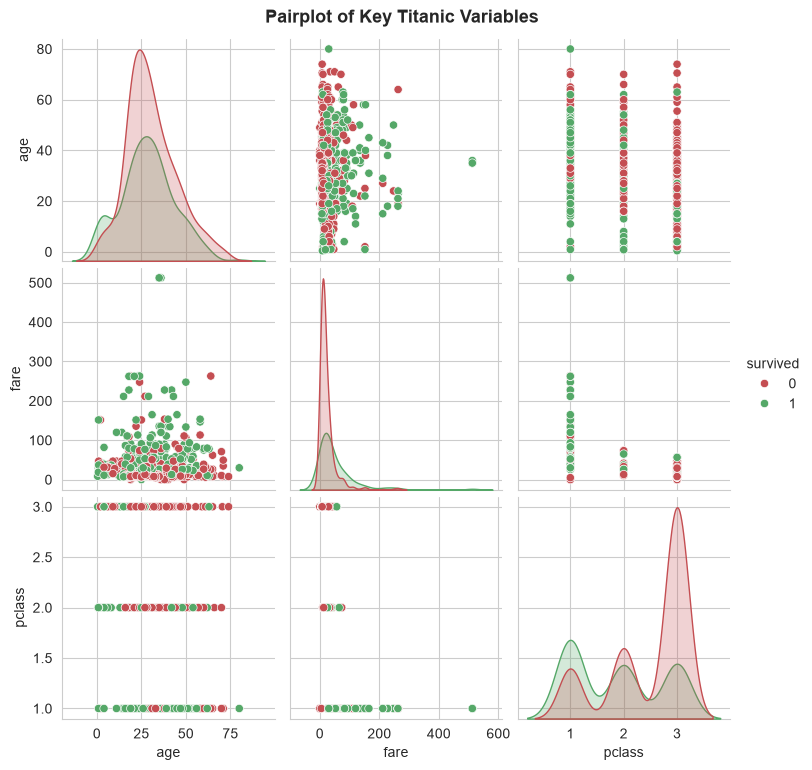

In [7]:
pairplot_cols = ["age", "fare", "pclass", "survived"]
sns.pairplot(df[pairplot_cols].dropna(), hue="survived", palette={0: "#C44E52", 1: "#55A868"}, diag_kind="kde")
plt.suptitle("Pairplot of Key Titanic Variables", y=1.02, fontsize=13, fontweight="bold")
plt.show()


**What this shows:** *(fill in — which pair of variables shows the clearest separation between
survivors and non-survivors? Anything worth investigating further?)*

---

## 🗂️ Step 5 — Full EDA Summary Table

Consolidating everything from this week into one reference table.


In [10]:
age = df["age"].dropna()
fare = df["fare"].dropna()

full_summary = pd.DataFrame({
    "Variable": ["age", "age", "age", "fare", "fare", "fare"],
    "Statistic": ["Mean", "Median", "Std Dev", "Mean", "Median", "Std Dev"],
    "Value": [round(age.mean(), 2), round(age.median(), 2), round(age.std(), 2),
              round(fare.mean(), 2), round(fare.median(), 2), round(fare.std(), 2)]
})

full_summary


,Variable,Statistic,Value
0,age,Mean,29.70
1,age,Median,28.00
2,age,Std Dev,14.53
3,fare,Mean,32.20
4,fare,Median,14.45
5,fare,Std Dev,49.69


## ✅ Step 6 — Key Takeaways

- The bivariate analysis confirmed what Day 4's outlier detection first suggested: fare is
  strongly tied to passenger class, with 1st class showing both the highest median fare and the
  widest spread, while 3rd class fares cluster tightly near the lower end.
- The age-vs-fare scatter plot, colored by survival, revealed that survivors tend to skew slightly
  younger and toward higher fares — hinting that both age and class-linked wealth may have played
  a role in survival outcomes.
- The correlation heatmap quantified these relationships numerically, showing `fare` and `pclass`
  as the strongest correlated pair among the numeric features — reinforcing the class-fare pattern
  seen visually throughout the week.
- The pairplot made the survival-based clustering visible across multiple variable pairs at once,
  confirming that no single variable alone perfectly separates survivors from non-survivors — a
  realistic reminder that real-world outcomes are rarely explained by one factor.
- Revisiting the class imbalance from Day 4 (3rd class ≈ 45% of passengers) alongside today's
  findings raises an important flag for future modeling: any survival prediction model must
  account for this imbalance, or risk being biased toward majority-class patterns rather than
  genuinely learning what drives survival.

---
Full Week 2 Narrative Summary
markdown
## 🧾 Full Week 2 Narrative Summary

This week began with the mathematical foundations of data analysis — descriptive statistics (Day
1) that taught how to summarize a single column with mean, median, and spread, and probability
(Day 2) that built intuition for uncertainty and conditional reasoning, culminating in a realistic
demonstration of how a low prior probability changes the meaning of even a highly accurate test.
Day 3 connected these ideas to how ML models actually compute: every dataset is a matrix, every
prediction is a dot product, and matrix multiplication scales that computation across every sample
at once.

Day 4 applied these statistical tools to the Titanic dataset for the first time, uncovering a
right-skewed fare distribution driven by genuine 1st class ticket prices and a significant class
imbalance favoring 3rd class passengers. Today's analysis extended that single-variable view into
relationships between variables — confirming that fare and class are closely linked, and that
survival correlates, at least loosely, with both age and fare. Taken together, the week's findings
paint a coherent picture of the dataset: a population unevenly distributed across class, with fare
and survival both shaped by that same class structure — exactly the kind of insight that should
guide any modeling decisions made in the weeks ahead.

---




## 📚 Resources

| Resource | Type | Focus |
|---|---|---|
| [Seaborn Documentation](https://seaborn.pydata.org/) | Docs | Statistical visualization reference |
| [Khan Academy — Correlation](https://www.khanacademy.org/math/statistics-probability/describing-relationships-quantitative-data) | Course / Video | Understanding correlation and scatter plots |

---

## ✍️ Author

**Zayan Shawareb**
BinX Tech — AI & Machine Learning Internship Program
Week 2, Day 5 — EDA Part 2: Correlation & Data Storytelling

---

## 🏁 Week 2 Complete

This notebook marks the completion of Week 2: Math Foundations & EDA. All five days —
Descriptive Statistics, Probability & Distributions, Linear Algebra, and EDA (Parts 1 & 2) — are
now documented and committed to GitHub.
